# TSMC next-day close: one compact FT-Transformer

**Ready to run; results are not precomputed.** This is one fixed, trainable PyTorch model, not a hyperparameter search. Each input is the master dataset's numeric information known after day `t` closes. The target is the next observed trading day's unadjusted `Close[t+1]` in USD.

The model tokenizes numeric **columns**, then attends across those feature tokens. It is an FT-Transformer-inspired tabular model rather than a Transformer attending across a long sequence of days. Trailing returns, close lags, moving averages, volatility, and momentum in the master CSV supply history. A final skip connection adds the model's learned correction to today's known close. This makes persistence the model's initial forecast and gives it a difficult baseline to improve on. The architecture is fixed and described in the methods section; its validation/test scores will determine whether it actually improves accuracy.

Designed for an RTX 3050 with 6 GB VRAM and 16 GB RAM: 35 input tokens plus one summary token, embedding width 32, four attention heads, two encoder layers, 64-unit feed-forward blocks, batch size 32, sequential model fits, at most 80 tuning epochs and 10-epoch patience. The dataset is stored as a small 2D array. GPU memory use has not been measured on your machine. A 15-minute soft training limit is checked after each epoch. A final refit on train + validation uses the epoch selected earlier and can take additional time.

The 70/15/15 ordered target-date split, target definition, and price metrics match the earlier notebooks. Persistence is the mandatory baseline. There is one validation-based early-stopping fit, followed by one refit of the same locked model on train + validation and a single final test evaluation. There is no architecture/feature search, seed selection, trading strategy, or profitability claim.

The local master CSV is generated from Yahoo Finance data, with a Google comparison elsewhere in the project. `Adj Close` is excluded because point-in-time adjustments are not documented. `Year` is excluded because a linear calendar-year value may act as an unreliable price-trend proxy; the other 35 available numeric fields are retained. Weekday/month/quarter are treated as ordinal values, a modeling simplification. The earlier project notebooks already inspected part of this historical test period, so report that limitation.


## 1. Libraries, fixed architecture, and resource settings

Install PyTorch suitable for your GPU and `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `joblib`, and Jupyter in the selected kernel. Run cells in order from the project directory or a child directory. The notebook creates `models/transformer/<run_id>/` only when run. No installation or model download occurs in the notebook.

Weights are trained with AdamW and scaled-price MSE. Device auto-selection prefers CUDA; setting `DEVICE_PREFERENCE='cpu'` before running this cell forces CPU. Fits never run in parallel, data loaders use zero workers, and PyTorch CPU threads are limited to two. If a CUDA out-of-memory error occurs, restart the kernel and use CPU. Do not interpret a nominal GPU memory size as a guarantee of free memory.


In [1]:
from pathlib import Path
import os
import random
import json
import time
import hashlib
import platform
import gc
from datetime import datetime, timezone

CPU_THREADS = min(2, os.cpu_count() or 1)
for env_name in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS'):
    os.environ[env_name] = str(CPU_THREADS)
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

try:
    import torch
except ImportError as exc:
    raise ImportError('Install PyTorch in this Jupyter kernel, then restart the kernel.') from exc
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, Markdown

SEED = 42
TRAIN_FRACTION, VALIDATION_FRACTION = 0.70, 0.15
EMBED_DIM, NUM_HEADS, NUM_LAYERS, FF_DIM = 32, 4, 2, 64
DROPOUT = 0.10
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 80
PATIENCE = 10
MIN_DELTA = 1e-6
MAX_TUNING_SECONDS = 900.0
GRADIENT_CLIP = 1.0
DEVICE_PREFERENCE = 'auto'  # Change to 'cpu' if necessary before running this cell.
assert DEVICE_PREFERENCE in {'auto', 'cpu'}
DEVICE = torch.device('cuda' if DEVICE_PREFERENCE == 'auto' and torch.cuda.is_available() else 'cpu')
torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass  # A reused kernel may already have initialized this pool.
torch.use_deterministic_algorithms(True, warn_only=True)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

set_seed()
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'Data' / 'TSMC_Master_Features_15Y.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Start Jupyter within the project containing Data/TSMC_Master_Features_15Y.csv.')
DATA_FILE = ROOT / 'Data' / 'TSMC_Master_Features_15Y.csv'
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
RUN_DIR = ROOT / 'models' / 'transformer' / RUN_ID
PLOT_DIR = RUN_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=False)
plt.style.use('seaborn-v0_8-whitegrid')

def finish_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Device:', DEVICE, 'CPU threads:', torch.get_num_threads())
print('PyTorch:', torch.__version__, '| outputs:', RUN_DIR)


Device: cuda CPU threads: 2
PyTorch: 2.11.0+cu128 | outputs: f:\SEM-7\Time Series Analysis\Project\models\transformer\20260927T035006308666Z


## 2. Audit master features and align tomorrow's target

The engineered columns are checked against trailing calculations using only present/past records. We then pair row `t` with `Close[t+1]`, retain `Origin_Date` and `Target_Date`, and drop the final unknown target and initial rolling-feature warm-up. `Adj Close` and `Year` are excluded from the model, while *all* original engineered columns still pass the common-row completeness audit so the evaluation dates match the existing notebooks. No missing values are backfilled from the future.

The data audit checks the local feature construction, not market-source authenticity. Preserve source/download metadata separately in the report.


In [2]:
raw = pd.read_csv(DATA_FILE)
raw['Date'] = pd.to_datetime(raw['Date'], errors='raise')
raw = raw.sort_values('Date').reset_index(drop=True)
assert raw['Date'].notna().all() and raw['Date'].is_unique, 'Missing or duplicate dates.'
assert raw['Date'].is_monotonic_increasing
numeric_columns = raw.columns.drop('Date').tolist()
raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors='raise')
assert not np.isinf(raw[numeric_columns].to_numpy()).any(), 'Infinite data values.'
assert (raw['Close'] > 0).all() and (raw['Volume'] >= 0).all()
tol = 1e-5
assert (raw['High'] + tol >= raw[['Open', 'Close', 'Low']].max(axis=1)).all()
assert (raw['Low'] - tol <= raw[['Open', 'Close', 'High']].min(axis=1)).all()

expected = {
    'Log_Close': np.log(raw['Close']),
    'Return_1D': raw['Close'].pct_change(fill_method=None),
    'Log_Return_1D': np.log(raw['Close']).diff(),
    'High_Low_Range': (raw['High'] - raw['Low']) / raw['Close'],
    'Open_Close_Change': (raw['Close'] - raw['Open']) / raw['Open'],
    'Day_of_Week': raw['Date'].dt.dayofweek,
    'Month': raw['Date'].dt.month, 'Quarter': raw['Date'].dt.quarter,
    'Year': raw['Date'].dt.year,
}
for lag in [1, 2, 3, 5, 10, 20]:
    expected[f'Close_Lag_{lag}'] = raw['Close'].shift(lag)
    expected[f'Return_Lag_{lag}'] = expected['Return_1D'].shift(lag)
for window in [5, 10, 20, 50]:
    expected[f'SMA_{window}'] = raw['Close'].rolling(window).mean()
for window in [5, 10, 20]:
    expected[f'Volatility_{window}'] = expected['Log_Return_1D'].rolling(window).std()
    expected[f'Momentum_{window}D'] = raw['Close'].pct_change(window, fill_method=None)
for name, values in expected.items():
    np.testing.assert_allclose(raw[name], values, rtol=1e-6, atol=1e-8,
                               equal_nan=True, err_msg=f'Feature mismatch: {name}')

audit = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum()})
display(audit)
print(f'{len(raw):,} rows; {len(raw.columns)} columns; '
      f"{raw['Date'].min().date()} through {raw['Date'].max().date()}")
print('Verified all engineered columns against causal trailing calculations.')
audit.to_csv(RUN_DIR / 'data_audit.csv')


,dtype,missing
Date,datetime64[ns],0
Open,float64,0
High,float64,0
Low,float64,0
Close,float64,0
Adj Close,float64,0
Volume,int64,0
Log_Close,float64,0
Return_1D,float64,1
Log_Return_1D,float64,1


3,771 rows; 38 columns; 2011-09-12 through 2026-09-10
Verified all engineered columns against causal trailing calculations.


## 3. Fix one feature set and the same chronological boundaries

Every row is a 35-column observation available after its own market close. The retained columns include current OHLCV, past close/return lags, moving averages, volatility, momentum, and calendar summaries. This is one fixed feature set. With just one model, no importance ranking or data-dependent feature pruning is used.

Splits follow target dates: the first 70% train, the next 15% validate stopping, and the final 15% test. Validation is used only to decide when to stop training this fixed architecture. The final model is refitted on train + validation for the locked number of epochs. Test values never fit a scaler, update weights, stop training, or select a setting.


,split,rows,first_origin,last_origin,first_target,last_target
0,train,2604,2011-11-18,2022-03-25,2011-11-21,2022-03-28
1,validation,558,2022-03-28,2024-06-14,2022-03-29,2024-06-17
2,test,559,2024-06-17,2026-09-09,2024-06-18,2026-09-10


,Origin_Date,Close,Target_Date,Target_Close
0,2011-11-18,12.66,2011-11-21,12.56
1,2011-11-21,12.56,2011-11-22,12.56
2,2011-11-22,12.56,2011-11-23,12.20
3,2011-11-23,12.20,2011-11-25,12.07
4,2011-11-25,12.07,2011-11-28,12.55


Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Log_Close', 'Return_1D', 'Log_Return_1D', 'High_Low_Range', 'Open_Close_Change', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Close_Lag_10', 'Close_Lag_20', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_10', 'Return_Lag_20', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'Momentum_5D', 'Momentum_10D', 'Momentum_20D', 'Day_of_Week', 'Month', 'Quarter']
Raw rows: 3771 | usable aligned observations: 3721


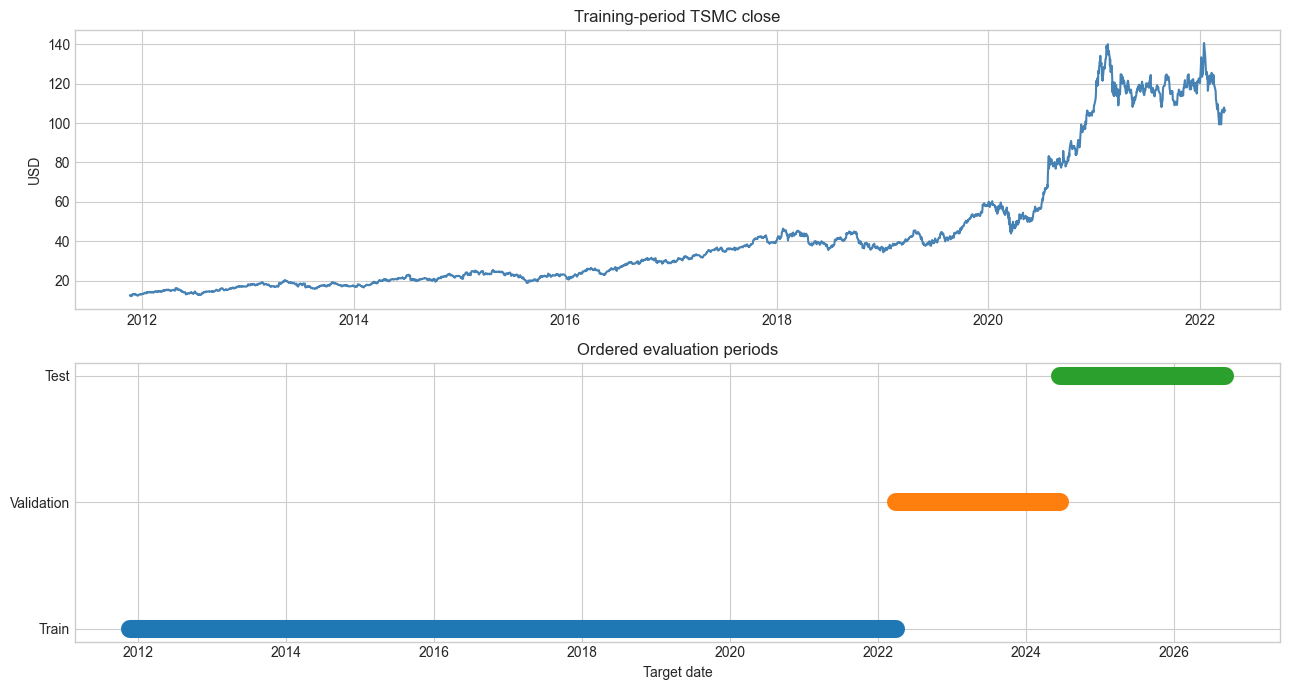

In [3]:
EXCLUDED = {'Date': 'Index only', 'Adj Close': 'Point-in-time adjustment unavailable',
            'Year': 'Avoid numeric year as a price-trend shortcut'}
ALL_ORIGINAL_FEATURES = [c for c in numeric_columns if c != 'Adj Close']
FEATURES = [c for c in numeric_columns if c not in EXCLUDED]
assert 'Close' in FEATURES and len(FEATURES) == 35
aligned = raw.rename(columns={'Date': 'Origin_Date'}).copy()
aligned['Target_Date'] = aligned['Origin_Date'].shift(-1)
aligned['Target_Close'] = aligned['Close'].shift(-1)
data = aligned.dropna(subset=ALL_ORIGINAL_FEATURES + ['Target_Date', 'Target_Close']).reset_index(drop=True)
assert len(data) > 500 and data['Target_Date'].is_unique
assert (data['Origin_Date'] < data['Target_Date']).all()
train_end = int(len(data) * TRAIN_FRACTION)
validation_end = int(len(data) * (TRAIN_FRACTION + VALIDATION_FRACTION))
train = data.iloc[:train_end].copy()
validation = data.iloc[train_end:validation_end].copy()
test = data.iloc[validation_end:].copy()
assert train['Target_Date'].max() < validation['Target_Date'].min()
assert validation['Target_Date'].max() < test['Target_Date'].min()
assert train['Target_Date'].iloc[-1] <= validation['Origin_Date'].iloc[0]
assert validation['Target_Date'].iloc[-1] <= test['Origin_Date'].iloc[0]

split_summary = pd.DataFrame([
    {'split': name, 'rows': len(frame),
     'first_origin': frame['Origin_Date'].min(), 'last_origin': frame['Origin_Date'].max(),
     'first_target': frame['Target_Date'].min(), 'last_target': frame['Target_Date'].max()}
    for name, frame in [('train', train), ('validation', validation), ('test', test)]])
display(split_summary)
display(data[['Origin_Date', 'Close', 'Target_Date', 'Target_Close']].head())
print('Features:', FEATURES)
print('Raw rows:', len(raw), '| usable aligned observations:', len(data))
split_summary.to_csv(RUN_DIR / 'splits.csv', index=False)
(RUN_DIR / 'features.json').write_text(json.dumps({'features': FEATURES, 'excluded': EXCLUDED}, indent=2), encoding='utf-8')

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].plot(train['Target_Date'], train['Target_Close'], color='steelblue')
axes[0].set(title='Training-period TSMC close', ylabel='USD')
for i, (name, frame) in enumerate([('Train', train), ('Validation', validation), ('Test', test)]):
    axes[1].plot([frame['Target_Date'].min(), frame['Target_Date'].max()], [i, i], linewidth=13)
axes[1].set(yticks=range(3), yticklabels=['Train', 'Validation', 'Test'],
            xlabel='Target date', title='Ordered evaluation periods')
finish_plot('01_data_and_splits')


## 4. Scale inputs and target using each fit period only

Volume is transformed with `log1p`; all inputs and the closing-price target are standardized using statistics learned on the current fitting period. `Close` at the forecast origin is transformed by the target scaler to form the skip connection. The output is mapped back to USD before scoring. Validation and test prices may be outside the training range and are never clipped. These scalers are saved with the model.

The array shape is `(rows, 35 features)`; unlike a temporal sequence Transformer, there is no 20- or 60-day window. Historical information comes from the lag and rolling columns already in the row.


In [4]:
def feature_values(frame):
    values = frame[FEATURES].astype(float).copy()
    values['Volume'] = np.log1p(values['Volume'])
    return values.to_numpy(dtype=np.float64)

def prepare(fit_frame, later_frame):
    x_scaler = StandardScaler().fit(feature_values(fit_frame))
    y_scaler = StandardScaler().fit(fit_frame[['Target_Close']].to_numpy(dtype=np.float64))
    x_fit = x_scaler.transform(feature_values(fit_frame)).astype(np.float32)
    x_later = x_scaler.transform(feature_values(later_frame)).astype(np.float32)
    y_fit = y_scaler.transform(fit_frame[['Target_Close']]).reshape(-1).astype(np.float32)
    y_later = y_scaler.transform(later_frame[['Target_Close']]).reshape(-1).astype(np.float32)
    anchor_fit = y_scaler.transform(fit_frame[['Close']]).reshape(-1).astype(np.float32)
    anchor_later = y_scaler.transform(later_frame[['Close']]).reshape(-1).astype(np.float32)
    for values in (x_fit, x_later, y_fit, y_later, anchor_fit, anchor_later):
        if not np.isfinite(values).all():
            raise ValueError('Non-finite scaled values.')
    return {'x_scaler': x_scaler, 'y_scaler': y_scaler, 'features': FEATURES,
            'volume_transform': 'log1p'}, (x_fit, anchor_fit, y_fit), (x_later, anchor_later, y_later)

def loader_from_arrays(arrays, shuffle=False):
    x, anchor, target = arrays
    dataset = TensorDataset(torch.from_numpy(x), torch.from_numpy(anchor), torch.from_numpy(target))
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, generator=generator,
                      num_workers=0, pin_memory=False, drop_last=False)

def score(frame, predictions, fit_frame):
    actual = frame['Target_Close'].to_numpy(dtype=np.float64)
    predicted = np.asarray(predictions, dtype=np.float64)
    origin = frame['Close'].to_numpy(dtype=np.float64)
    assert actual.shape == predicted.shape and np.isfinite(predicted).all()
    mae = float(mean_absolute_error(actual, predicted))
    mse = float(mean_squared_error(actual, predicted))
    rmse = float(np.sqrt(mse))
    persistence_rmse = float(np.sqrt(mean_squared_error(actual, origin)))
    scale = float(np.mean(np.abs(fit_frame['Target_Close'] - fit_frame['Close'])))
    if persistence_rmse <= 0 or scale <= 0:
        raise ValueError('Degenerate persistence baseline.')
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse,
            'MAPE_pct': float(np.mean(np.abs((actual - predicted) / actual)) * 100),
            'R2': float(r2_score(actual, predicted)), 'MASE': mae / scale,
            'Direction_accuracy_pct': float(np.mean(np.sign(predicted - origin) == np.sign(actual - origin)) * 100),
            'RMSE_skill_pct': (1 - rmse / persistence_rmse) * 100}


## 5. The one fixed FT-Transformer architecture

For numeric feature `j` with standardized value `x_j`, the tokenizer forms a learned vector `x_j W_j + b_j`. A learned summary token is appended. Two Transformer encoder blocks allow attention across the feature tokens; the summary-token output feeds a small price-correction head. Dropout, weight decay, and a small embedding are deliberate regularization for 3,721 usable observations.

The correction head starts at zero, so the first forecast equals today's close. The model learns to depart from persistence only when historical training data support it. This architecture does **not** attend over time directly: close lags and trailing indicators provide time context. Attention across columns should not be interpreted as causal feature importance.


In [5]:
class CompactFTTransformer(nn.Module):
    def __init__(self, n_features=35, embed_dim=32, heads=4, layers=2, ff_dim=64, dropout=0.10):
        super().__init__()
        if embed_dim % heads:
            raise ValueError('Embedding width must be divisible by attention heads.')
        self.feature_weight = nn.Parameter(torch.empty(n_features, embed_dim))
        self.feature_bias = nn.Parameter(torch.zeros(n_features, embed_dim))
        self.summary_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.normal_(self.feature_weight, std=0.02)
        nn.init.normal_(self.summary_token, std=0.02)
        block = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads,
                                            dim_feedforward=ff_dim, dropout=dropout,
                                            activation='gelu', batch_first=True,
                                            norm_first=True)
        self.encoder = nn.TransformerEncoder(block, num_layers=layers, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(embed_dim)
        self.output_dropout = nn.Dropout(dropout)
        self.head = nn.Linear(embed_dim, 1)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, features, scaled_origin_close):
        tokens = features.unsqueeze(-1) * self.feature_weight + self.feature_bias
        cls = self.summary_token.expand(features.size(0), -1, -1)
        encoded = self.encoder(torch.cat([cls, tokens], dim=1))
        correction = self.head(self.output_dropout(self.norm(encoded[:, 0]))).squeeze(-1)
        return scaled_origin_close + correction

MODEL_CONFIG = {'n_features': len(FEATURES), 'embed_dim': EMBED_DIM,
                'heads': NUM_HEADS, 'layers': NUM_LAYERS, 'ff_dim': FF_DIM, 'dropout': DROPOUT}
model = CompactFTTransformer(**MODEL_CONFIG).to(DEVICE)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print('Trainable parameters:', parameter_count)
assert parameter_count < 100_000, 'This notebook is intended to remain a compact model.'
model.eval()
with torch.no_grad():
    check_features = torch.zeros(2, len(FEATURES), device=DEVICE)
    check_anchor = torch.tensor([0.1, -0.2], device=DEVICE)
    check_output = model(check_features, check_anchor)
    torch.testing.assert_close(check_output, check_anchor)
print('Shape and initial persistence check passed.')
del model, check_features, check_anchor, check_output
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()


Trainable parameters: 19457
Shape and initial persistence check passed.


## 6. Train one model with validation-based early stopping

Only the first 70% of target dates fit weights/scalers here. After every epoch, compute scaled-price MSE on the next 15% in evaluation mode. Save the lowest-loss weights; stop when validation loss fails to improve by `MIN_DELTA` for `PATIENCE` epochs or when the time budget is reached at an epoch boundary. The lowest-loss weights are restored even if the patience criterion and absolute minimum differ.

Training batches are shuffled *within the historical training period*: each row is an independent supervised example, so batch order does not reveal future validation/test labels. Model initialization and shuffling use the fixed seed. No feature, layer, or learning-rate variants are tried. Validation determines training duration only.


f:\Programs\PYTHON_310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
f:\Programs\PYTHON_310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
f:\Programs\PYTHON_310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
f:\Programs\PYTHON_310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
f:\Programs\PYTHON_310\lib\site-packages\torch\autograd\graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at C:\actions-ru

Epoch 01: train MSE=0.00134895, validation MSE=0.00465948
Epoch 10: train MSE=0.00129387, validation MSE=0.00467506


,MAE,MSE,RMSE,MAPE_pct,R2,MASE,Direction_accuracy_pct,RMSE_skill_pct
model,,,,,,,,
FT_Transformer,1.609541,4.963756,2.227949,1.625890,0.990272,2.609433,47.670251,0.166221
Persistence,1.607186,4.980299,2.231658,1.622008,0.990239,2.605615,0.179211,0.000000


Best epoch: 1 | stopped by: early_stopping


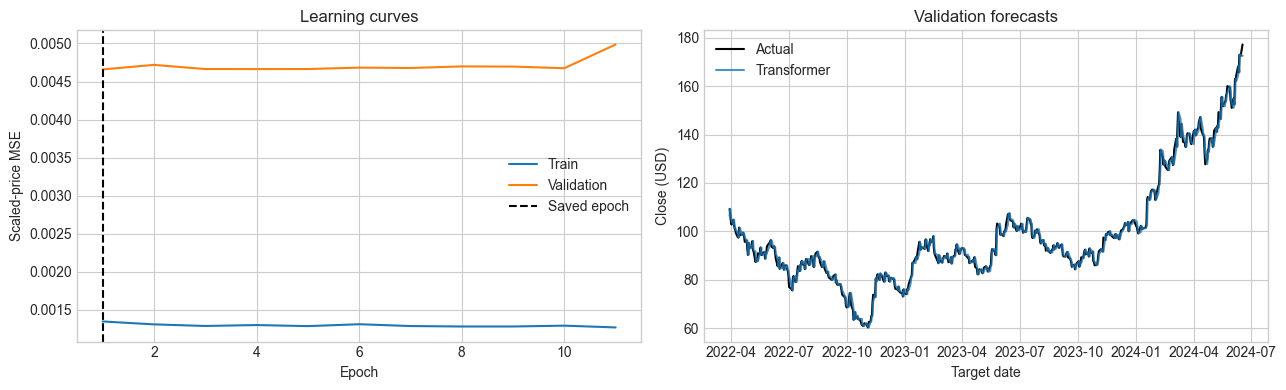

In [6]:
def one_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total, count = 0.0, 0
    with torch.set_grad_enabled(training):
        for x, anchor, y in loader:
            x, anchor, y = x.to(DEVICE), anchor.to(DEVICE), y.to(DEVICE)
            if training:
                optimizer.zero_grad(set_to_none=True)
            prediction = model(x, anchor)
            loss = nn.functional.mse_loss(prediction, y)
            if not torch.isfinite(loss):
                raise FloatingPointError('Non-finite training loss.')
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP, error_if_nonfinite=True)
                optimizer.step()
            total += float(loss.detach().cpu()) * len(y)
            count += len(y)
    return total / count

@torch.no_grad()
def predict_usd(model, loader, preprocessing):
    model.eval()
    batches = []
    for x, anchor, _ in loader:
        output = model(x.to(DEVICE), anchor.to(DEVICE))
        batches.append(output.cpu().numpy())
    scaled = np.concatenate(batches).reshape(-1, 1)
    prediction = preprocessing['y_scaler'].inverse_transform(scaled.astype(np.float64)).reshape(-1)
    if not np.isfinite(prediction).all():
        raise FloatingPointError('Non-finite forecasts.')
    return prediction

preprocessing, train_arrays, validation_arrays = prepare(train, validation)
train_loader = loader_from_arrays(train_arrays, shuffle=True)
validation_loader = loader_from_arrays(validation_arrays)
set_seed()
model = CompactFTTransformer(**MODEL_CONFIG).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
best_loss, reference_loss, best_epoch, stale = float('inf'), float('inf'), 0, 0
best_state = None
curve = []
stop_reason = 'max_epochs'
started = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = one_epoch(model, train_loader, optimizer)
    validation_loss = one_epoch(model, validation_loader)
    elapsed = time.perf_counter() - started
    curve.append({'epoch': epoch, 'train_scaled_MSE': train_loss,
                  'validation_scaled_MSE': validation_loss, 'elapsed_seconds': elapsed})
    if validation_loss < best_loss:
        best_loss, best_epoch = validation_loss, epoch
        best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
    if validation_loss < reference_loss - MIN_DELTA:
        reference_loss, stale = validation_loss, 0
    else:
        stale += 1
    if epoch == 1 or epoch % 10 == 0:
        print(f'Epoch {epoch:02d}: train MSE={train_loss:.6g}, validation MSE={validation_loss:.6g}', flush=True)
    if stale >= PATIENCE:
        stop_reason = 'early_stopping'
        break
    if elapsed >= MAX_TUNING_SECONDS:
        stop_reason = 'time_budget'
        break
if best_state is None:
    raise RuntimeError('No finite validation checkpoint.')
model.load_state_dict(best_state)
validation_predictions = predict_usd(model, validation_loader, preprocessing)
validation_metrics = pd.DataFrame({
    'FT_Transformer': score(validation, validation_predictions, train),
    'Persistence': score(validation, validation['Close'].to_numpy(), train),
}).T
validation_metrics.index.name = 'model'
display(validation_metrics)
print('Best epoch:', best_epoch, '| stopped by:', stop_reason)
if validation_metrics.loc['FT_Transformer', 'RMSE'] >= validation_metrics.loc['Persistence', 'RMSE']:
    print('The Transformer did not beat persistence on validation. Report this outcome.')
pd.DataFrame(curve).to_csv(RUN_DIR / 'learning_curve.csv', index=False)
validation_metrics.to_csv(RUN_DIR / 'validation_metrics.csv')
validation_export = validation[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
validation_export['Prediction'] = validation_predictions
validation_export['Persistence'] = validation['Close'].to_numpy()
validation_export.to_csv(RUN_DIR / 'validation_predictions.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
curve_df = pd.DataFrame(curve)
axes[0].plot(curve_df['epoch'], curve_df['train_scaled_MSE'], label='Train')
axes[0].plot(curve_df['epoch'], curve_df['validation_scaled_MSE'], label='Validation')
axes[0].axvline(best_epoch, color='black', linestyle='--', label='Saved epoch')
axes[0].set(title='Learning curves', xlabel='Epoch', ylabel='Scaled-price MSE')
axes[0].legend()
axes[1].plot(validation['Target_Date'], validation['Target_Close'], label='Actual', color='black')
axes[1].plot(validation['Target_Date'], validation_predictions, label='Transformer', alpha=0.8)
axes[1].set(title='Validation forecasts', xlabel='Target date', ylabel='Close (USD)')
axes[1].legend()
finish_plot('02_validation')
del optimizer, model
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()


## 7. Refit the same architecture on train + validation and save it

The architecture and epoch count are now fixed. Refit fresh scalers and a fresh model on the first 85% of target dates, for the previously selected `best_epoch` epochs. This second fit is still the **same fixed model specification**. It uses no early stopping or data from test. Its model state is saved before test prediction; test observations never update the weights.

Save the CPU `state_dict`, feature order, model config, and both scalers. The checkpoint contains tensors and simple built-in values, so PyTorch can reload it with `weights_only=True`. A small generated architecture module supports later inference without rerunning the notebook. Only load the companion joblib file if it came from this trusted run.


In [7]:
history = pd.concat([train, validation], ignore_index=True)
assert history['Target_Date'].max() <= test['Origin_Date'].min()
final_preprocessing, history_arrays, test_arrays = prepare(history, test)
history_loader = loader_from_arrays(history_arrays, shuffle=True)
test_loader = loader_from_arrays(test_arrays)
set_seed()
final_model = CompactFTTransformer(**MODEL_CONFIG).to(DEVICE)
final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
final_curve = []
final_started = time.perf_counter()
for epoch in range(1, best_epoch + 1):
    final_loss = one_epoch(final_model, history_loader, final_optimizer)
    final_curve.append({'epoch': epoch, 'train_scaled_MSE': final_loss})
    if epoch == 1 or epoch % 10 == 0 or epoch == best_epoch:
        print(f'Final refit {epoch}/{best_epoch}: MSE={final_loss:.6g}', flush=True)
final_fit_seconds = time.perf_counter() - final_started
final_model.eval()
pd.DataFrame(final_curve).to_csv(RUN_DIR / 'final_training_curve.csv', index=False)
MODEL_FILE = RUN_DIR / 'selected_model.pt'
PREPROCESSING_FILE = RUN_DIR / 'preprocessing.joblib'
torch.save({'state_dict': {name: value.detach().cpu().clone() for name, value in final_model.state_dict().items()},
            'model_config': MODEL_CONFIG, 'features': FEATURES, 'epochs': best_epoch,
            'seed': SEED, 'target': 'next trading day unadjusted Close in USD'}, MODEL_FILE)
joblib.dump(final_preprocessing, PREPROCESSING_FILE)
model_definition = '''from torch import nn
import torch

class CompactFTTransformer(nn.Module):
    def __init__(self, n_features=35, embed_dim=32, heads=4, layers=2, ff_dim=64, dropout=0.10):
        super().__init__()
        if embed_dim % heads:
            raise ValueError('Embedding width must be divisible by attention heads.')
        self.feature_weight = nn.Parameter(torch.empty(n_features, embed_dim))
        self.feature_bias = nn.Parameter(torch.zeros(n_features, embed_dim))
        self.summary_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.normal_(self.feature_weight, std=0.02)
        nn.init.normal_(self.summary_token, std=0.02)
        block = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads,
                                            dim_feedforward=ff_dim, dropout=dropout,
                                            activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(block, num_layers=layers, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(embed_dim)
        self.output_dropout = nn.Dropout(dropout)
        self.head = nn.Linear(embed_dim, 1)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)
    def forward(self, features, scaled_origin_close):
        tokens = features.unsqueeze(-1) * self.feature_weight + self.feature_bias
        cls = self.summary_token.expand(features.size(0), -1, -1)
        encoded = self.encoder(torch.cat([cls, tokens], dim=1))
        correction = self.head(self.output_dropout(self.norm(encoded[:, 0]))).squeeze(-1)
        return scaled_origin_close + correction
'''
(RUN_DIR / 'model_definition.py').write_text(model_definition, encoding='utf-8')
print('Saved model and preprocessing:', RUN_DIR)


f:\Programs\PYTHON_310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
f:\Programs\PYTHON_310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
f:\Programs\PYTHON_310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
f:\Programs\PYTHON_310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Final refit 1/1: MSE=0.00147195
Saved model and preprocessing: f:\SEM-7\Time Series Analysis\Project\models\transformer\20260927T035006308666Z


## 8. Evaluate the reserved test period once

Forecast each next trading day from the known current-day features. The fixed model can use current and previously observed market data at each origin; it does not retrain between test rows. Report dollar errors and persistence on **identical dates**, including MAE, MSE, RMSE, MAPE, R², MASE, and sign accuracy. A high price-level R² can hide failure against persistence. Direction accuracy is a forecast diagnostic, not a realized trading return.

Reload the saved state and scalers on CPU and reproduce its first test batch as a saved-artifact check. Small float32 differences between GPU and CPU are allowed. No test metric changes architecture or epoch selection.


In [8]:
test_predictions = predict_usd(final_model, test_loader, final_preprocessing)
test_metrics = pd.DataFrame({
    'FT_Transformer': score(test, test_predictions, history),
    'Persistence': score(test, test['Close'].to_numpy(), history),
}).T
test_metrics.index.name = 'model'
display(test_metrics)
test_metrics.to_csv(RUN_DIR / 'test_metrics.csv')
test_export = test[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
test_export['Prediction'] = test_predictions
test_export['Persistence'] = test['Close'].to_numpy()
test_export['Error_actual_minus_predicted'] = test_export['Target_Close'] - test_predictions
test_export['Predicted_return'] = test_predictions / test_export['Close'] - 1
test_export['Actual_return'] = test_export['Target_Close'] / test_export['Close'] - 1
test_export.to_csv(RUN_DIR / 'test_predictions.csv', index=False)

saved = torch.load(MODEL_FILE, map_location='cpu', weights_only=True)
saved_preprocessing = joblib.load(PREPROCESSING_FILE)
reload_x = saved_preprocessing['x_scaler'].transform(feature_values(test.iloc[:BATCH_SIZE])).astype(np.float32)
reload_anchor = saved_preprocessing['y_scaler'].transform(test.iloc[:BATCH_SIZE][['Close']]).reshape(-1).astype(np.float32)
reload_model = CompactFTTransformer(**saved['model_config'])
reload_model.load_state_dict(saved['state_dict'])
reload_model.eval()
with torch.no_grad():
    scaled_reload = reload_model(torch.from_numpy(reload_x), torch.from_numpy(reload_anchor)).numpy().reshape(-1, 1)
reloaded_prices = saved_preprocessing['y_scaler'].inverse_transform(scaled_reload).reshape(-1)
np.testing.assert_allclose(reloaded_prices, test_predictions[:len(reloaded_prices)], atol=2e-3, rtol=1e-5)
print('Saved-model reload check passed.')
del reload_model, reload_x, reload_anchor, final_optimizer
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()


,MAE,MSE,RMSE,MAPE_pct,R2,MASE,Direction_accuracy_pct,RMSE_skill_pct
model,,,,,,,,
FT_Transformer,5.209642,54.599728,7.389163,1.96200,0.993514,6.581258,53.130590,0.163588
Persistence,5.232576,54.778805,7.401270,1.96797,0.993493,6.610230,0.178891,0.000000


Saved-model reload check passed.


f:\Programs\PYTHON_310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## 9. Forecast and error plots

Plot the full test path and a 90-day close-up; inspect actual-versus-predicted prices, daily errors, a 20-observation rolling MAE comparison with persistence, and predicted versus actual returns. Price lines often overlap even when next-day change forecasts are poor, so the error and return views matter.


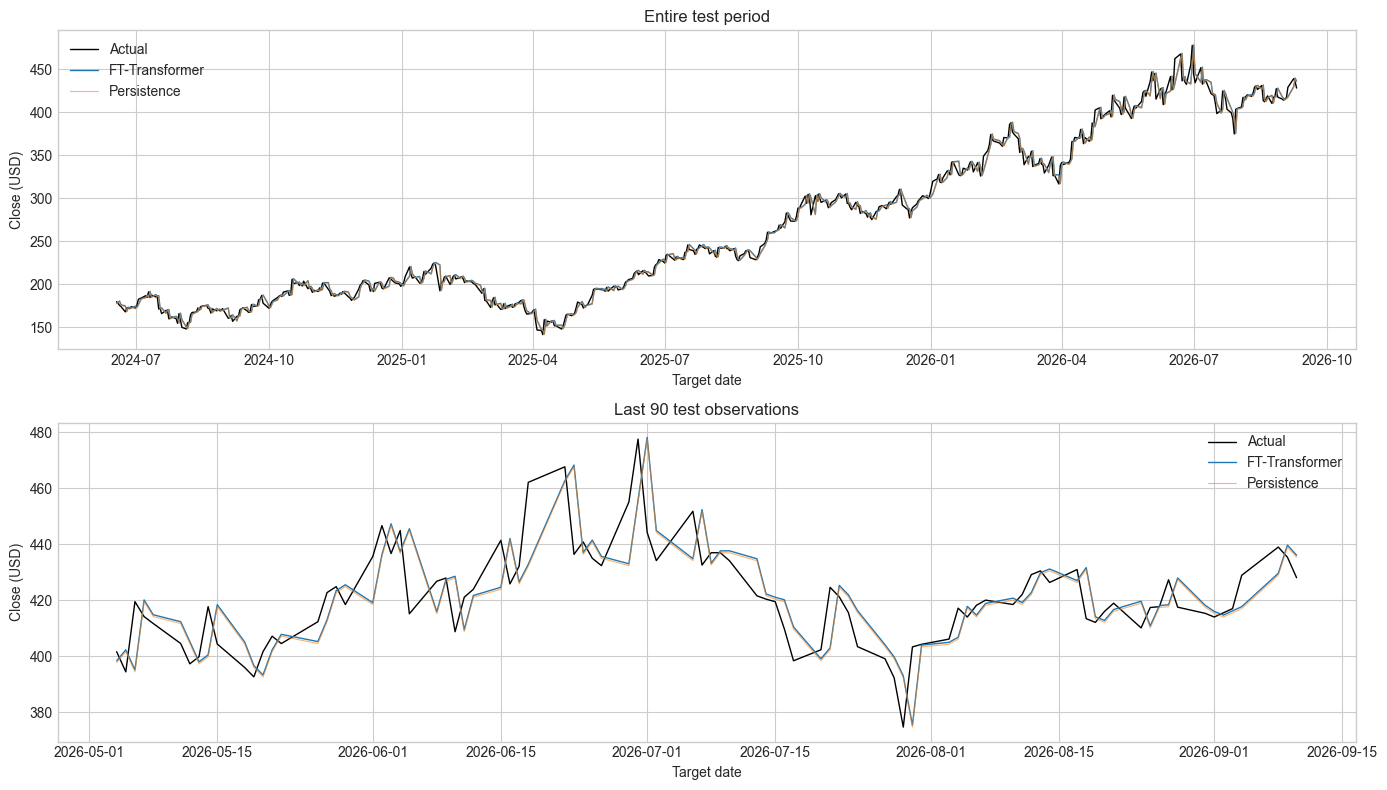

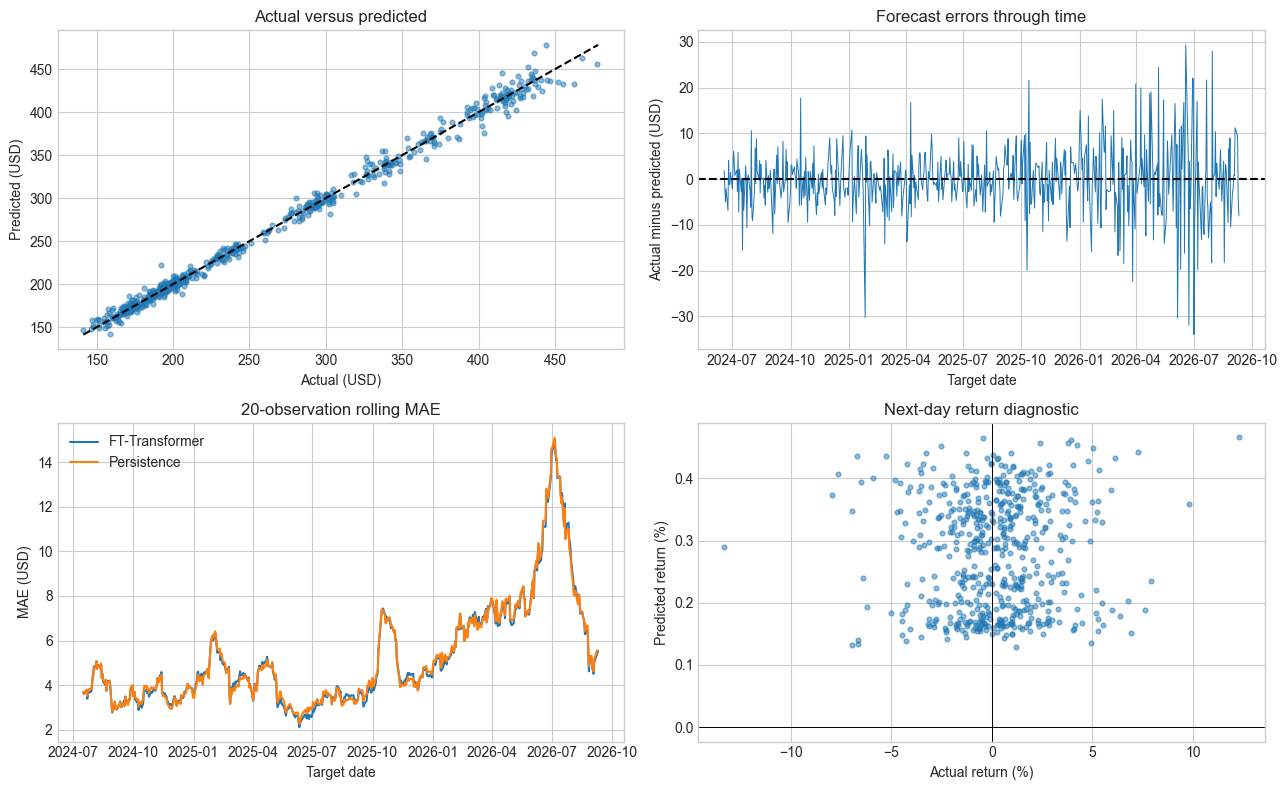

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax, frame, title in [(axes[0], test_export, 'Entire test period'),
                         (axes[1], test_export.tail(90), 'Last 90 test observations')]:
    ax.plot(frame['Target_Date'], frame['Target_Close'], color='black', label='Actual', linewidth=1)
    ax.plot(frame['Target_Date'], frame['Prediction'], label='FT-Transformer', linewidth=1)
    ax.plot(frame['Target_Date'], frame['Persistence'], label='Persistence', linewidth=0.8, alpha=0.6)
    ax.set(title=title, xlabel='Target date', ylabel='Close (USD)')
    ax.legend()
finish_plot('03_test_forecasts')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].scatter(test_export['Target_Close'], test_export['Prediction'], s=12, alpha=0.5)
limits = [min(test_export['Target_Close'].min(), test_export['Prediction'].min()),
          max(test_export['Target_Close'].max(), test_export['Prediction'].max())]
axes[0, 0].plot(limits, limits, '--', color='black')
axes[0, 0].set(title='Actual versus predicted', xlabel='Actual (USD)', ylabel='Predicted (USD)')
axes[0, 1].plot(test_export['Target_Date'], test_export['Error_actual_minus_predicted'], linewidth=0.7)
axes[0, 1].axhline(0, color='black', linestyle='--')
axes[0, 1].set(title='Forecast errors through time', xlabel='Target date', ylabel='Actual minus predicted (USD)')
for column, label in [('Prediction', 'FT-Transformer'), ('Persistence', 'Persistence')]:
    rolling = (test_export['Target_Close'] - test_export[column]).abs().rolling(20).mean()
    axes[1, 0].plot(test_export['Target_Date'], rolling, label=label)
axes[1, 0].set(title='20-observation rolling MAE', xlabel='Target date', ylabel='MAE (USD)')
axes[1, 0].legend()
axes[1, 1].scatter(test_export['Actual_return'] * 100, test_export['Predicted_return'] * 100,
                   s=12, alpha=0.5)
axes[1, 1].axhline(0, color='black', linewidth=0.7)
axes[1, 1].axvline(0, color='black', linewidth=0.7)
axes[1, 1].set(title='Next-day return diagnostic', xlabel='Actual return (%)', ylabel='Predicted return (%)')
finish_plot('04_test_errors')


## 10. Manifest and report-ready interpretation

Save the source hash, exact split dates, feature order, fixed architecture, training limits, saved epoch, package versions, metrics, and limitations. A `latest_run.json` pointer is written only after this cell finishes. A previous interrupted run may leave partial files; do not treat those as completed results.

The conclusion distinguishes validated accuracy from profitability. If persistence has lower validation/test RMSE, report it. This notebook cannot promise accurate forecasts for changing stock-market conditions. It also does not establish trading returns, transaction counts, or Buy/Sell/Hold rules.


In [10]:
selected_validation = validation_metrics.loc['FT_Transformer']
baseline_validation = validation_metrics.loc['Persistence']
selected_test = test_metrics.loc['FT_Transformer']
baseline_test = test_metrics.loc['Persistence']
validation_verdict = ('beat' if selected_validation['RMSE'] < baseline_validation['RMSE'] else 'did not beat')
test_verdict = ('beat' if selected_test['RMSE'] < baseline_test['RMSE'] else 'did not beat')
manifest = {
    'run_id': RUN_ID, 'source_file': str(DATA_FILE.relative_to(ROOT)),
    'source_sha256': hashlib.sha256(DATA_FILE.read_bytes()).hexdigest(),
    'provenance': 'Master derived from local Yahoo Finance data; Google comparison in project.',
    'raw_rows': len(raw), 'aligned_rows': len(data), 'features': FEATURES, 'excluded': EXCLUDED,
    'target': 'Next observed trading day unadjusted Close in USD',
    'forecast_origin': 'After the current trading day closes',
    'splits': json.loads(split_summary.to_json(orient='records', date_format='iso')),
    'architecture': MODEL_CONFIG, 'parameter_count': parameter_count,
    'learning_rate': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY, 'batch_size': BATCH_SIZE,
    'max_epochs': MAX_EPOCHS, 'early_stop_patience': PATIENCE, 'min_delta': MIN_DELTA,
    'max_tuning_seconds': MAX_TUNING_SECONDS, 'stopping_reason': stop_reason,
    'selected_epoch': best_epoch, 'final_fit_seconds': final_fit_seconds,
    'seed': SEED, 'device': str(DEVICE), 'cpu_threads': torch.get_num_threads(),
    'validation_metrics': json.loads(validation_metrics.to_json(orient='index')),
    'test_metrics': json.loads(test_metrics.to_json(orient='index')),
    'prior_test_exposure': 'Earlier project notebooks inspected part of the historical test period.',
    'versions': {'python': platform.python_version(), 'torch': str(torch.__version__),
                 'numpy': np.__version__, 'pandas': pd.__version__, 'sklearn': sklearn.__version__},
}
(RUN_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2, allow_nan=False), encoding='utf-8')
summary = f'''# FT-Transformer next-day TSMC closing-price forecast

- One fixed model: {parameter_count:,} parameters; {len(FEATURES)} numeric inputs; {NUM_LAYERS} encoder layers; width {EMBED_DIM}; {NUM_HEADS} heads.
- Training: one validation-stopped fit, best epoch {best_epoch}, stopping reason {stop_reason}; fresh refit on train + validation for {best_epoch} epochs.
- Validation: RMSE **${selected_validation['RMSE']:.4f}**, MAE **${selected_validation['MAE']:.4f}**; persistence RMSE **${baseline_validation['RMSE']:.4f}**. The Transformer {validation_verdict} persistence.
- Test: MAE **${selected_test['MAE']:.4f}**, MSE **{selected_test['MSE']:.4f} USD²**, RMSE **${selected_test['RMSE']:.4f}**, MAPE **{selected_test['MAPE_pct']:.3f}%**, R² **{selected_test['R2']:.5f}**.
- Test persistence RMSE: **${baseline_test['RMSE']:.4f}**. The Transformer {test_verdict} it. Test direction accuracy: **{selected_test['Direction_accuracy_pct']:.2f}%**.
- Limits: a single stock and validation period, no architecture search, deterministic seed subject to cross-device variability, model attention across columns rather than days, and prior exposure of part of the test period in earlier notebooks.
- Profitability and trading strategy have not been tested in this model notebook.
'''
display(Markdown(summary))
(RUN_DIR / 'summary.md').write_text(summary, encoding='utf-8')
(ROOT / 'models' / 'transformer' / 'latest_run.json').write_text(
    json.dumps({'run_id': RUN_ID, 'directory': str(RUN_DIR.relative_to(ROOT))}, indent=2), encoding='utf-8')
print('Completed run:', RUN_DIR)


# FT-Transformer next-day TSMC closing-price forecast

- One fixed model: 19,457 parameters; 35 numeric inputs; 2 encoder layers; width 32; 4 heads.
- Training: one validation-stopped fit, best epoch 1, stopping reason early_stopping; fresh refit on train + validation for 1 epochs.
- Validation: RMSE **$2.2279**, MAE **$1.6095**; persistence RMSE **$2.2317**. The Transformer beat persistence.
- Test: MAE **$5.2096**, MSE **54.5997 USD²**, RMSE **$7.3892**, MAPE **1.962%**, R² **0.99351**.
- Test persistence RMSE: **$7.4013**. The Transformer beat it. Test direction accuracy: **53.13%**.
- Limits: a single stock and validation period, no architecture search, deterministic seed subject to cross-device variability, model attention across columns rather than days, and prior exposure of part of the test period in earlier notebooks.
- Profitability and trading strategy have not been tested in this model notebook.


Completed run: f:\SEM-7\Time Series Analysis\Project\models\transformer\20260927T035006308666Z
